# LIKWID policy-* summary

Run this notebook from a policy folder such as `performance/` or `ondemand/`.
It auto-detects subfolders like `<policy>-*` and computes:
- Total runtime [s]
- Average total power [W]
- Total energy [J]
- EDP [J*s]

In [5]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Sequence

import matplotlib.pyplot as plt
import pandas as pd

# Settings
base_dir = Path('.')  # run from policy folder (e.g., performance/, ondemand/)
policy_name = base_dir.resolve().name
subfolder_pattern = f'{policy_name}-*'
benchmark_name = None  # None => process all detected benchmarks; set to a name to filter
skip_initial = 3
output_dir = base_dir  # per-benchmark CSV files are written here

SUM_FIELDS = {
    'Energy [J]',
    'Power [W]',
    'Energy PP0 [J]',
    'Power PP0 [W]',
    'Energy DRAM [J]',
    'Power DRAM [W]',
    'Energy PLATFORM [J]',
    'Power PLATFORM [W]',
    'Memory read bandwidth [MBytes/s]',
    'Memory read data volume [GBytes]',
    'Memory write bandwidth [MBytes/s]',
    'Memory write data volume [GBytes]',
    'Memory bandwidth [MBytes/s]',
    'Memory data volume [GBytes]',
    'L3 request rate',
    'L3 miss rate',
    'L3 miss ratio',
    'Energy Core [J]',
    'Power Core [W]',
    'Energy L3 [J]',
    'Power L3 [W]',
}



In [6]:
def extract_job_id(path: Path | str) -> str:
    name = path.name if isinstance(path, Path) else Path(path).name
    parts = name.split('.')
    if len(parts) < 3:
        raise ValueError(f'Could not infer job id from {name}')
    return parts[-2]


def _stdout_candidates(folder: Path, job_id: str) -> List[Path]:
    pattern = f'*.{job_id}.out'
    matches = sorted(folder.rglob(pattern))
    return [
        path
        for path in matches
        if 'timeline' not in path.name and not path.name.startswith('likwid_')
    ]


def find_stdout_for_job(base: Path, job_id: str) -> Path:
    search_roots = [base, base.parent]
    candidates: List[Path] = []
    for root in search_roots:
        if root.exists():
            candidates.extend(_stdout_candidates(root, job_id))
    if not candidates:
        raise FileNotFoundError(f'No stdout file found for job {job_id} under {base.parent}')
    return sorted(candidates)[0]


FATAL_MARKERS = [
    'fatal error',
    'abort(',
    'job step aborted',
    'cancelled',
    'exited with exit code',
]


def file_has_fatal_error(path: Path) -> bool:
    with path.open(errors='ignore') as handle:
        for line in handle:
            lower = line.lower()
            if any(marker in lower for marker in FATAL_MARKERS):
                return True
    return False


def run_has_fatal_error(profile_path: Path, stdout_path: Path) -> tuple[bool, str]:
    if file_has_fatal_error(profile_path):
        return True, profile_path.name
    if file_has_fatal_error(stdout_path):
        return True, stdout_path.name
    return False, ''


def parse_headers(stdout_path: Path) -> List[Sequence[str]]:
    headers: List[Sequence[str]] = []
    with stdout_path.open() as handle:
        for line in handle:
            if line.startswith('# GID|'):
                parts = line.lstrip('#').strip().split('|')
                fields = parts[3:]
                if fields:
                    headers.append(fields)
    if not headers:
        raise RuntimeError(f'No LIKWID headers found in {stdout_path}')
    return headers


def aggregate_metric(values: Sequence[float], field: str) -> float:
    if not values:
        raise KeyError(f'Missing values for field {field}')
    if field in SUM_FIELDS:
        return float(sum(values))
    return float(sum(values) / len(values))


def load_likwid_profile(profile_path: Path, stdout_path: Path, *, skip_initial: int = 0) -> pd.DataFrame:
    headers = parse_headers(stdout_path)
    header = headers[0]
    global_field = header[0]
    metric_fields = header[1:]

    rows: List[Dict[str, float]] = []
    with profile_path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line or not line[0].isdigit():
                continue
            parts = line.split(',')
            if len(parts) < 4:
                continue
            gid = int(parts[0])
            metrics_count = int(parts[1])
            cpu_count = int(parts[2])
            values = [float(val) for val in parts[3:]]

            expected_values = 1 + metrics_count * cpu_count
            if metrics_count != len(metric_fields) or len(values) != expected_values:
                raise ValueError(f'Header/data mismatch in {profile_path.name}')

            global_value = values[0]
            metric_values = values[1:]

            extracted: Dict[str, float] = {global_field: global_value}
            for idx, field in enumerate(metric_fields):
                start = idx * cpu_count
                end = start + cpu_count
                extracted[field] = aggregate_metric(metric_values[start:end], field)

            extracted['gid'] = gid
            rows.append(extracted)

    if skip_initial:
        rows = rows[skip_initial:]

    if not rows:
        raise RuntimeError(f'No LIKWID samples parsed from {profile_path.name}')

    return pd.DataFrame(rows).reset_index(drop=True)


def summarize_profile(df: pd.DataFrame) -> Dict[str, float]:
    required_fields = ['Power Core [W]', 'Power L3 [W]']
    missing = [field for field in required_fields if field not in df.columns]
    if missing:
        raise ValueError(f'Missing columns for power/energy calculations: {missing}')

    # Keep original data as much as possible; remove only extremely large power spikes
    sample_mask = pd.Series(True, index=df.index)
    for power_field in ['Power Core [W]', 'Power L3 [W]']:
        series = df[power_field]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        if iqr > 0:
            high = q3 + 10.0 * iqr
        else:
            high = float(series.max())
        sample_mask &= series.notna() & (series >= 0.0) & (series <= high)

    filtered_df = df.loc[sample_mask].reset_index(drop=True)
    removed_samples = len(df) - len(filtered_df)
    if removed_samples > 0:
        print(f'Removed {removed_samples} extreme-high LIKWID samples using automatic power filtering')
    if filtered_df.empty:
        raise ValueError('All LIKWID samples were filtered out due to extreme power values')

    if 'Total runtime [s]' in filtered_df.columns:
        time_axis = filtered_df['Total runtime [s]']
        total_runtime = float(time_axis.iloc[-1])
    else:
        time_axis = filtered_df.index
        total_runtime = float(time_axis[-1] - time_axis[0]) if len(time_axis) > 1 else 0.0

    time_values = time_axis.to_numpy()
    core_power = filtered_df['Power Core [W]'].to_numpy()
    l3_power = filtered_df['Power L3 [W]'].to_numpy()

    avg_total_power = float(filtered_df['Power Core [W]'].mean() + filtered_df['Power L3 [W]'].mean())

    if len(time_values) > 1:
        dt = time_values[1:] - time_values[:-1]
        total_core_energy = float((core_power[:-1] + core_power[1:]).dot(dt) / 2.0)
        total_l3_energy = float((l3_power[:-1] + l3_power[1:]).dot(dt) / 2.0)
    else:
        total_core_energy = 0.0
        total_l3_energy = 0.0

    total_energy = total_core_energy + total_l3_energy
    edp = total_energy * total_runtime

    return {
        'Total runtime [s]': total_runtime,
        'Average total power [W]': avg_total_power,
        'Total energy [J]': total_energy,
        'EDP [J*s]': edp,
    }


def list_profiles(profiles_dir: Path) -> pd.DataFrame:
    profile_paths = sorted(profiles_dir.glob('*.prof'))
    profile_table = []
    for path in profile_paths:
        parts = path.stem.split('.')
        name = parts[0].removeprefix('spechpc_')
        job = parts[1] if len(parts) > 1 else ''
        profile_table.append({'benchmark': name, 'job_id': job, 'path': path})
    return pd.DataFrame(profile_table).sort_values(['benchmark', 'job_id'])


def newest_profile_for_benchmark(profiles_df: pd.DataFrame, benchmark: str | None = None) -> Path:
    if benchmark is None:
        benchmark = str(profiles_df['benchmark'].value_counts().index[0])
    match = profiles_df[profiles_df['benchmark'] == benchmark]
    if match.empty:
        raise ValueError(f'No profiles found for benchmark {benchmark}')
    return Path(match.sort_values('job_id').iloc[-1]['path'])


In [7]:
rows = []
for subdir in sorted(base_dir.glob(subfolder_pattern)):
    if not subdir.is_dir():
        continue

    profiles_dir = subdir / 'profiles'
    if not profiles_dir.is_dir():
        continue

    profiles_df = list_profiles(profiles_dir)
    if profiles_df.empty:
        continue

    benchmarks = sorted(profiles_df['benchmark'].unique())
    if benchmark_name is not None:
        if benchmark_name not in benchmarks:
            continue
        benchmarks = [benchmark_name]

    for benchmark in benchmarks:
        profile_file = newest_profile_for_benchmark(profiles_df, benchmark)
        job_id = extract_job_id(profile_file)
        stdout_file = find_stdout_for_job(subdir, job_id)
        has_fatal, fatal_source = run_has_fatal_error(profile_file, stdout_file)
        if has_fatal:
            print(f"Skipping {subdir.name}/{benchmark}: found fatal error markers in {fatal_source}")
            continue

        df = load_likwid_profile(profile_file, stdout_file, skip_initial=skip_initial)
        metrics = summarize_profile(df)
        metrics['subfolder'] = subdir.name
        metrics['benchmark'] = benchmark
        rows.append(metrics)

if not rows:
    raise RuntimeError(f'No valid runs found with pattern: {subfolder_pattern}')

summary = pd.DataFrame(rows)
summary = summary[[
    'subfolder',
    'benchmark',
    'Total runtime [s]',
    'Average total power [W]',
    'Total energy [J]',
    'EDP [J*s]',
]]
summary = summary.sort_values(['benchmark', 'subfolder']).reset_index(drop=True)

per_benchmark_summary: Dict[str, pd.DataFrame] = {}
for benchmark, bench_df in summary.groupby('benchmark', sort=True):
    bench_df = bench_df.sort_values('subfolder').reset_index(drop=True)

    # Detect abnormal runs per benchmark; only remove extreme-high values
    abnormal_metrics = ['Average total power [W]', 'Total energy [J]', 'EDP [J*s]']
    abnormal_mask = pd.Series(False, index=bench_df.index)
    for metric in abnormal_metrics:
        q1 = bench_df[metric].quantile(0.25)
        q3 = bench_df[metric].quantile(0.75)
        iqr = q3 - q1
        if iqr > 0:
            high = q3 + 10.0 * iqr
            abnormal_mask |= bench_df[metric] > high

    abnormal_runs = bench_df.loc[abnormal_mask, 'subfolder'].tolist()
    if abnormal_runs:
        print(f"[{benchmark}] Detected abnormal runs with extreme-high values (excluded from plots/averages/csv): {', '.join(abnormal_runs)}")

    bench_for_plot = bench_df.loc[~abnormal_mask].copy()
    if bench_for_plot.empty:
        print(f"[{benchmark}] All runs were flagged as abnormal; skipping benchmark")
        continue

    # Remove only extreme-high outliers before computing averages
    outlier_metrics = ['Average total power [W]', 'Total energy [J]', 'EDP [J*s]']
    outlier_mask = pd.Series(False, index=bench_for_plot.index)
    for metric in outlier_metrics:
        q1 = bench_for_plot[metric].quantile(0.25)
        q3 = bench_for_plot[metric].quantile(0.75)
        iqr = q3 - q1
        if iqr > 0:
            high = q3 + 6.0 * iqr
            outlier_mask |= bench_for_plot[metric] > high

    outlier_runs = bench_for_plot.loc[outlier_mask, 'subfolder'].tolist()
    if outlier_runs:
        print(f"[{benchmark}] Detected extreme-high outlier runs (excluded from averages): {', '.join(outlier_runs)}")

    bench_for_average = bench_for_plot.loc[~outlier_mask].copy()
    if bench_for_average.empty:
        print(f"[{benchmark}] All non-abnormal runs were outliers; skipping benchmark")
        continue

    average_row = {
        'subfolder': 'Average',
        'benchmark': benchmark,
        'Total runtime [s]': bench_for_average['Total runtime [s]'].mean(),
        'Average total power [W]': bench_for_average['Average total power [W]'].mean(),
        'Total energy [J]': bench_for_average['Total energy [J]'].mean(),
        'EDP [J*s]': bench_for_average['EDP [J*s]'].mean(),
    }

    output_df = pd.concat([bench_for_plot, pd.DataFrame([average_row])], ignore_index=True)
    output_df = output_df.sort_values('subfolder').reset_index(drop=True)
    output_df = output_df.round(2)

    csv_path = output_dir / f'{policy_name}_summary_{benchmark}.csv'
    output_df.to_csv(csv_path, index=False, float_format='%.2f')
    per_benchmark_summary[benchmark] = output_df
    print(f'[{benchmark}] Wrote: {csv_path.resolve()}')

if not per_benchmark_summary:
    raise RuntimeError('No benchmark produced valid output after filtering')

all_output = pd.concat(per_benchmark_summary.values(), ignore_index=True)
all_output = all_output.sort_values(['benchmark', 'subfolder']).reset_index(drop=True)

print(f'Policy folder: {policy_name}')
print(f'Subfolder pattern: {subfolder_pattern}')
if benchmark_name is None:
    print('Benchmark filter: all detected benchmarks')
else:
    print(f'Benchmark filter: {benchmark_name}')

all_output



Removed 4 extreme-high LIKWID samples using automatic power filtering
Removed 4 extreme-high LIKWID samples using automatic power filtering
Removed 5 extreme-high LIKWID samples using automatic power filtering
Removed 4 extreme-high LIKWID samples using automatic power filtering
Removed 7 extreme-high LIKWID samples using automatic power filtering
[amg] Wrote: /mnt/REPACSS/home/li29729/Research2025/CPUfreq/PrimeMicroBenchmarks/tests/AMG/AMDzen4c/ondemand/ondemand_summary_amg.csv
Policy folder: ondemand
Subfolder pattern: ondemand-*
Benchmark filter: all detected benchmarks


,subfolder,benchmark,Total runtime [s],Average total power [W],Total energy [J],EDP [J*s]
0,Average,amg,460.61,595.84,273635.78,1.260575e+08
1,ondemand-0,amg,452.93,594.90,268795.34,1.217445e+08
2,ondemand-1,amg,451.54,605.86,272924.54,1.232366e+08
3,ondemand-2,amg,462.58,598.74,275919.28,1.276357e+08
4,ondemand-3,amg,460.98,595.86,273998.55,1.263077e+08
5,ondemand-4,amg,475.02,583.81,276541.19,1.313629e+08


Removed 4 extreme-high samples from 'Power L3 [W]' using upper bound 920


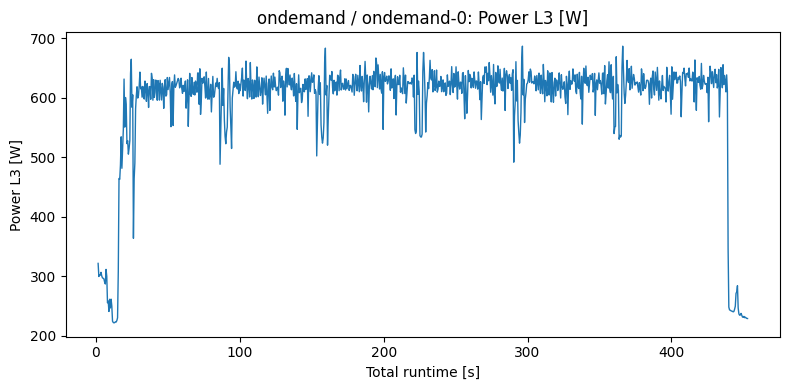

In [8]:
# Plot LIKWID sample time-series for one subfolder and one field
selected_subfolder = 'ondemand-0'
selected_field = 'Power L3 [W]'

subdir = base_dir / selected_subfolder
profiles_dir = subdir / 'profiles'
if not profiles_dir.is_dir():
    raise FileNotFoundError(f'Profiles directory not found: {profiles_dir}')

profiles_df = list_profiles(profiles_dir)
if profiles_df.empty:
    raise RuntimeError(f'No profile files found in {profiles_dir}')

profile_file = newest_profile_for_benchmark(profiles_df, benchmark_name)
job_id = extract_job_id(profile_file)
stdout_file = find_stdout_for_job(subdir, job_id)
has_fatal, fatal_source = run_has_fatal_error(profile_file, stdout_file)
if has_fatal:
    raise RuntimeError(f"Selected subfolder {selected_subfolder} contains fatal error markers in {fatal_source}")
ts_df = load_likwid_profile(profile_file, stdout_file, skip_initial=skip_initial)

if selected_field not in ts_df.columns:
    raise KeyError(f"Field '{selected_field}' not found. Available fields: {sorted(ts_df.columns)}")

# Automatically remove only extreme-high outlier samples
plot_df = ts_df.copy()
q1 = plot_df[selected_field].quantile(0.25)
q3 = plot_df[selected_field].quantile(0.75)
iqr = q3 - q1
if iqr > 0:
    high = q3 + 10.0 * iqr
    before = len(plot_df)
    plot_df = plot_df[plot_df[selected_field] <= high].copy()
    removed = before - len(plot_df)
    if removed:
        print(f"Removed {removed} extreme-high samples from '{selected_field}' using upper bound {high:.3g}")

if plot_df.empty:
    raise RuntimeError('No samples left to plot after automatic outlier filtering')

x = plot_df['Total runtime [s]'] if 'Total runtime [s]' in plot_df.columns else plot_df.index

plt.figure(figsize=(8, 4))
plt.plot(x, plot_df[selected_field], linewidth=1)
plt.title(f"{policy_name} / {selected_subfolder}: {selected_field}")
plt.xlabel('Total runtime [s]' if 'Total runtime [s]' in plot_df.columns else 'sample index')
plt.ylabel(selected_field)
plt.tight_layout()
plt.show()


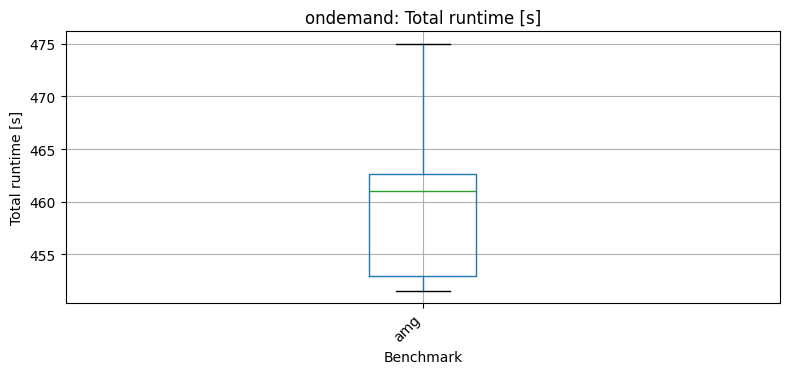

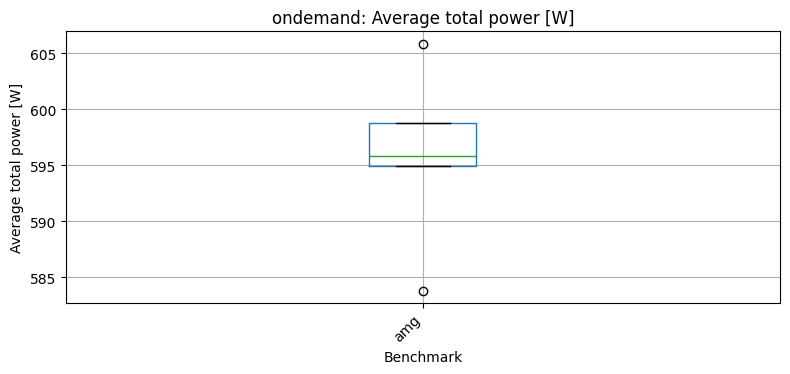

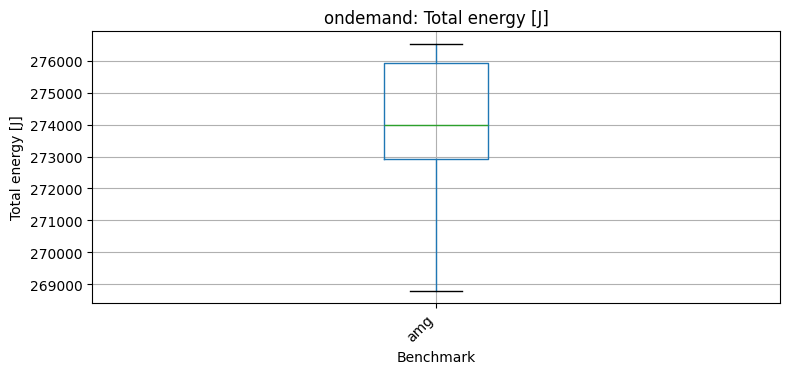

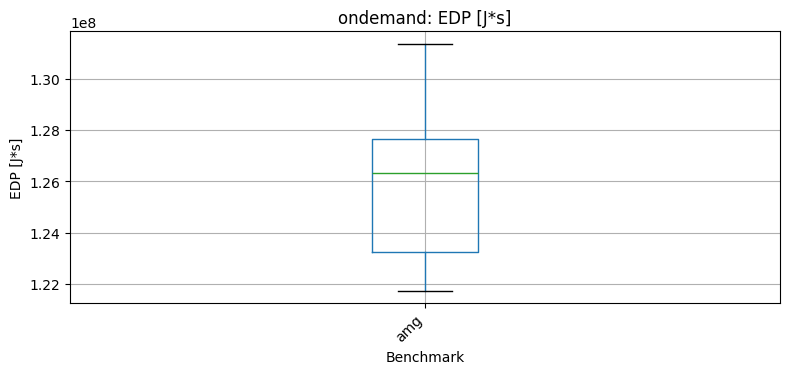

In [9]:
plot_metrics = [
    'Total runtime [s]',
    'Average total power [W]',
    'Total energy [J]',
    'EDP [J*s]',
]

if 'per_benchmark_summary' not in globals() or not per_benchmark_summary:
    raise RuntimeError('Run the summary cell first to populate per_benchmark_summary')

plot_df = pd.concat(per_benchmark_summary.values(), ignore_index=True)
plot_df = plot_df[plot_df['subfolder'] != 'Average'].copy()
if plot_df.empty:
    raise RuntimeError('No run-level rows available for plotting')

benchmark_order = sorted(plot_df['benchmark'].unique())

for metric in plot_metrics:
    ax = plot_df.boxplot(column=metric, by='benchmark', figsize=(max(8, len(benchmark_order) * 0.6), 4))
    ax.set_title(f'{policy_name}: {metric}')
    ax.set_xlabel('Benchmark')
    ax.set_ylabel(metric)
    ax.set_xticklabels(benchmark_order, rotation=45, ha='right')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

